<a href="https://colab.research.google.com/github/matthewmorrice/Machine-Learning-Diagnosis-of-Diabetic-Eye-Disease-/blob/main/Data_Integration_Feature_fusion_and_Ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extract Images and Numerical Data

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display

# Import dataset
data = pd.read_csv('/content/drive/MyDrive/AI Coursework/Biomarker_Clinical_Data_Images_2.csv (17KB)')
display(data)

base_dir = '/content/drive/MyDrive/AI Coursework/Extracted Images'
image_paths = data.iloc[:,0]
full_paths = []

for path in image_paths:
  path = base_dir + path
  full_paths.append(path)

disease_labels = data.iloc[:,20]

images = []
labels = []

import cv2

# Load images and labels
for path, label in zip(full_paths, disease_labels):
    img = cv2.imread(path)

    if img is not None:  # Check if the image was successfully loaded
        img = cv2.resize(img, (224, 224))  # Resize to desired dimensions
        images.append(img)
        labels.append(label)
    else:
        print(f"Warning: Could not load image at path {path}")

# Convert lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

images = images.astype('float32')  # Convert to float32
images /= 255.0  # Normalize to [0, 1]

print(f"Loaded {len(images)} images and {len(labels)} labels.")

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)
labels = to_categorical(labels) # Convert labels to one-hot

,Path,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,Biomarker 5,Biomarker 6,Biomarker 7,Biomarker 8,Biomarker 9,...,Biomarker 11,Biomarker 12,Biomarker 13,Biomarker 14,Biomarker 15,Biomarker 16,Eye_ID,BCVA,CST,Disease Label
0,/TREX DME/GILA/0201GOD/V1/OD/TREXJ_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,1,0,0,0,1,61,575,DME
1,/TREX DME/GILA/0201GOD/V22/OD/TREX_DME_000024.tif,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,0,1,71,241,DME
2,/TREX DME/GILA/0203GOS/V1/OS/TREXS_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,0,0,0,0,2,80,392,DME
3,/TREX DME/GILA/0203GOS/V15/OS/TREX_DME_000024.tif,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,2,85,270,DME
4,/TREX DME/GILA/0204GOS/V1/OS/TREXD_000024.tif,0,0,0,0,1,1,0,0,0,...,1,1,0,0,0,0,3,62,539,DME
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,/Prime_FULL/02-044/W36/OS/24.tif,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,94,86,199,DR
188,/Prime_FULL/02-045/W0/OS/24.tif,0,0,0,0,1,0,0,0,0,...,1,1,1,0,0,0,95,74,302,DR
189,/Prime_FULL/02-045/W104/OS/24.tif,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,95,68,222,DR
190,/Prime_FULL/02-046/W0/OD/24.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,96,89,283,DR


Loaded 187 images and 187 labels.


**Feature Fusion With CNN**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 7s/step - accuracy: 0.6171 - loss: 1.8752 - val_accuracy: 0.4667 - val_loss: 1.6862
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.6564 - loss: 1.5479 - val_accuracy: 0.6000 - val_loss: 1.6140
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 0.6173 - loss: 1.5114 - val_accuracy: 0.6333 - val_loss: 1.4403
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 0.7620 - loss: 1.2644 - val_accuracy: 0.8333 - val_loss: 1.2896
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.7562 - loss: 1.2613 - val_accuracy: 0.8667 - val_loss: 1.2189
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.7894 - loss: 1.1888 - val_accuracy: 0.8333 - val_loss: 1.2128
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.8257 - loss: 1.0826 - val_accuracy: 0.8333 - val_loss: 1.1698
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.8650 - loss: 1.0272 - val_accuracy: 0.9333 - va

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)                   │ (None, 224, 224, 96)        │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 112, 112, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 110, 110, 192)       │         166,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 55, 55, 192)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 580800)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 384)                 │     223,027,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 2)                   │             770 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,591,368 (2.49 GB)

 Trainable params: 223,197,122 (851.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 446,394,246 (1.66 GB)

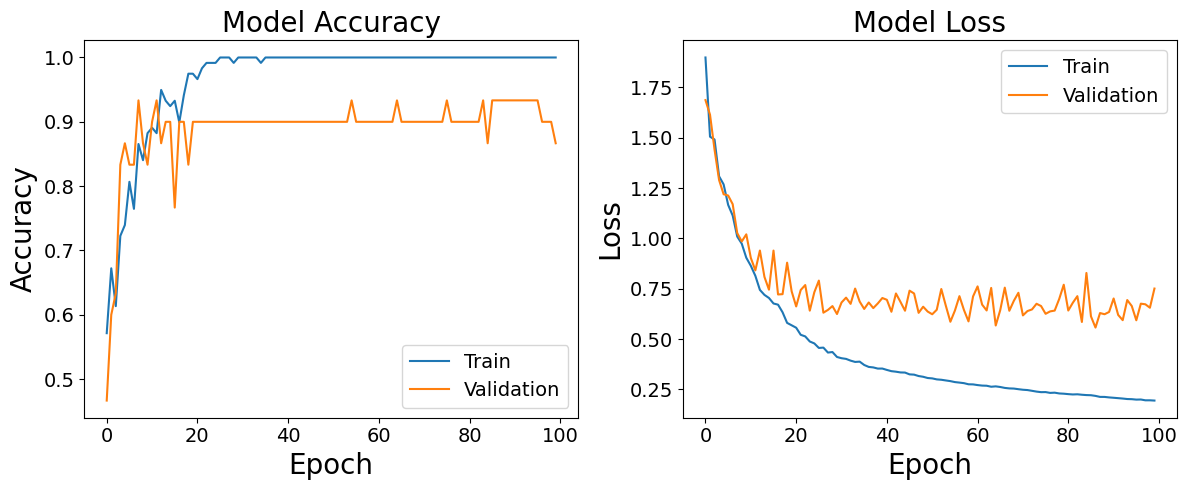

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step
Accuracy: 0.7894736842105263
Precision: 0.8215384615384616
Recall: 0.7894736842105263
F1-Score: 0.7840909090909092
Average ROC AUC (OvR): 0.7894736842105263


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Split the data into training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)

img_rows = images.shape[1]
img_cols = images.shape[2]
img_channels = images.shape[3]
num_classes = labels.shape[1]
num_filters = 96

# Build the model
model = Sequential()
model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
                 input_shape=(img_rows, img_cols, img_channels), padding = 'same',
                 dilation_rate = 2))#, kernel_regularizer=l1(0.01)))
model.add(MaxPool2D(2))
model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(MaxPool2D(2))
model.add(Flatten())
model.add(Dense(num_filters*4, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.00011114688286547925)))

# model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
#                  input_shape=(img_rows, img_cols, img_channels), padding = 'same',
#                  dilation_rate = 2, kernel_regularizer=l1(0.01)))
# model.add(MaxPool2D(2))

# model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu'))
# model.add(MaxPool2D(2))
# model.add(Conv2D(num_filters*4, kernel_size=3, activation='relu'))
# model.add(MaxPool2D(2))
# model.add(Conv2D(num_filters*16, kernel_size=3, activation='relu'))
# model.add(MaxPool2D(2))

# model.add(Flatten())
# model.add(Dropout(0.5))
# model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01)))

# Original: {'num_filters': 2(num_classes), 'dropout_rate': not included, 'learning rate': default}
# Best hyperparameters: {'num_filters': 64, 'dropout_rate': 0.5, 'learning_rate': 0.00019340055723859404}
# Best is trial 17 with value: 0.9473684430122375.
# Best hyperparameters: {'num_filters': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.004175448911645524}
# Best is trial 50 with value: 0.9210526347160339.
# Best hyperparameters: {'num_filters': 128, 'dropout_rate': 0.5, 'learning_rate': 0.000327537895887467, 'num_conv_layers': 3, 'kernel_size': (3, 3)}

# Trial 6 finished with value: 0.7894737124443054 and parameters: {'num_filters': 96, 'dropout_rate': 0.4, 'learning_rate': 4.893049541904633e-05, 'num_conv_layers': 1, 'kernel_size': (3, 3), 'l2_reg': 0.00011114688286547925}. Best is trial 3 with value: 0.8947368264198303.
# Accuracy Volatility: 0.05203425305381234
# Loss Volatility: 0.07663184908094117
# Trial 8 finished with value: 0.8157894611358643 and parameters: {'num_filters': 96, 'dropout_rate': 0.4, 'learning_rate': 6.795437943260704e-05, 'num_conv_layers': 1, 'kernel_size': (5, 5), 'l2_reg': 0.00013255743051051084}. Best is trial 3 with value: 0.8947368264198303.
# Accuracy Volatility: 0.08962834689954162
# Loss Volatility: 0.08499667155596147
# Trial 13 finished with value: 0.7105262875556946 and parameters: {'num_filters': 32, 'dropout_rate': 0.30000000000000004, 'learning_rate': 1.0537714653158082e-05, 'num_conv_layers': 2, 'kernel_size': (3, 3), 'l2_reg': 0.0012096665030932115}. Best is trial 3 with value: 0.8947368264198303.
# Accuracy Volatility: 0.11130675566244849
# Loss Volatility: 0.055192297883607175

# Compile the model
model.compile(optimizer=Adam(learning_rate=4.893049541904633e-05), loss='categorical_crossentropy', metrics=['accuracy'])
# model.compile(optimizer=Adam(learning_rate=0.000327537895887467), loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model to the training data
history = model.fit(images_train, labels_train, validation_split=0.2, epochs=100)
history_original = history

# Evaluate the performance on the test data
evaluation_result = model.evaluate(images_test, labels_test)
print("Test Accuracy:", evaluation_result[1])

model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(['Train', 'Validation'], loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

labels_pred = model.predict(images_test)
labels_pred = np.argmax(labels_pred, axis=1)
labels_test = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")

In [ ]:
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Specify the file path within your Drive
file_path = '/content/drive/My Drive/history_original.pkl'  # Choose your desired location

# Save the variable
with open(file_path, 'wb') as f:
    pickle.dump(history_original, f)

print(f"Variable 'history_original' saved to: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variable 'history_original' saved to: /content/drive/My Drive/history_original.pkl


In [ ]:
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Specify the file path
file_path = '/content/drive/My Drive/history_original.pkl'  # Use the same path as before

# Load the variable
with open(file_path, 'rb') as f:
    history_original = pickle.load(f)

print("Variable 'history_original' loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variable 'history_original' loaded.


     Biomarker 2  Biomarker 7  Biomarker 11  Biomarker 12  BCVA  CST
0              0            1             1             1    61  575
1              1            1             0             1    71  241
2              0            1             1             1    80  392
3              0            0             0             0    85  270
4              0            0             1             1    62  539
..           ...          ...           ...           ...   ...  ...
187            0            1             0             0    86  199
188            0            0             1             1    74  302
189            0            0             0             0    68  222
190            0            0             0             0    89  283
191            0            0             0             0    82  259

[192 rows x 6 columns]
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.5737 - loss: 1.7434 - val_accuracy: 0.4737 - val_loss: 1.6578
Epoch 2/100
5/5 ━━━━━━━

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 96)   │          2,688 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 96)   │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 110, 110, 192)  │        166,080 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 55, 55, 192)    │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 580800)         │              0 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 6)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 580806)         │              0 │ flatten[0][0],         │
│                           │                        │                │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 384)            │    223,029,888 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 384)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 2)              │            770 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 669,598,280 (2.49 GB)

 Trainable params: 223,199,426 (851.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 446,398,854 (1.66 GB)

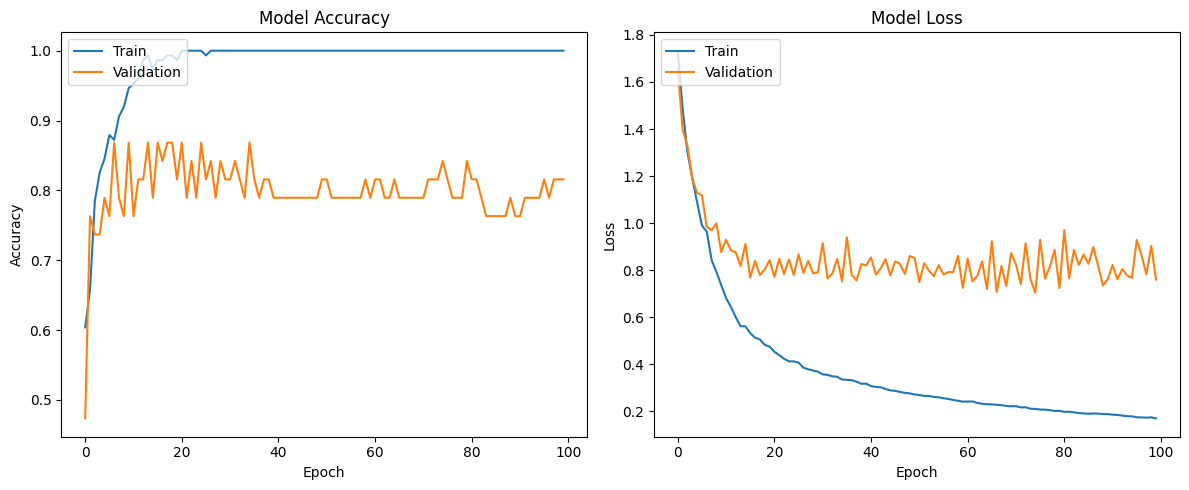

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, concatenate, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Extract the most important binary Biomarkers (11, 12, 2 and 7)
biomarkers = data.iloc[:, [2, 7, 11, 12]]

# Extract numerical Clinical Labels
clinical_labels = data.iloc[:, [18,19]]

# Extract Biomarkers and Clinical Labels
all_data = data.iloc[:, [2, 7, 11, 12] + [18, 19]]

# Extract data
X = all_data
print(all_data)
x = StandardScaler().fit_transform(X)  # Scale data
x = pd.DataFrame(x) # Convert back to dataframe

y = data['Disease Label']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = to_categorical(y)

# Get the paths of successfully loaded images
loaded_image_paths = [path for path, img in zip(full_paths, images) if img is not None]

# Get the indices of absent images
absent_image_indices = [i for i, path in enumerate(full_paths) if path not in loaded_image_paths]

# Remove corresponding data from the original dataframes
x = x[~x.index.isin(absent_image_indices)]
data = data[~data.index.isin(absent_image_indices)]


eye_ids = data['Eye_ID']

# Create a GroupShuffleSplit instance
splitter = GroupShuffleSplit(test_size=0.2, random_state=42)  # Adjust test_size and random_state as needed

# Split data into training and testing sets
for train_indices, test_indices in splitter.split(x, groups=eye_ids):
    x_train = x.iloc[train_indices]
    x_test = x.iloc[test_indices]
    y_train = data.iloc[train_indices]['Disease Label']  # Assuming 'Disease Label' is the target column
    y_test = data.iloc[test_indices]['Disease Label']


# Split the image data into training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)

img_rows = images.shape[1]
img_cols = images.shape[2]
img_channels = images.shape[3]
num_classes = labels.shape[1]

numerical_data = x
num_numerical_features = numerical_data.shape[1]

# Define input layers
image_input = Input(shape=(img_rows, img_cols, img_channels)) # Image input shape
numerical_input = Input(shape=(num_numerical_features,))  # Shape of numerical features

# CNN branch
# x = Conv2D(32, (3, 3), activation='relu')(image_input)
# x = MaxPooling2D((2, 2))(x)
# x = Conv2D(64, (3, 3), activation='relu')(x)
# x = MaxPooling2D((2, 2))(x)
# x = Flatten()(x)

x = Conv2D(96, kernel_size=3, activation='relu', padding='same', dilation_rate=2)(image_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(96*2, kernel_size=3, activation='relu', kernel_regularizer=l2(0.0011114688286547925))(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)

# # Build the model
# model = Sequential()
# model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
#                  input_shape=(img_rows, img_cols, img_channels), padding = 'same',
#                  dilation_rate = 2))#, kernel_regularizer=l1(0.01)))
# model.add(MaxPool2D(2))
# model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
# model.add(MaxPool2D(2))
# model.add(Flatten())
# model.add(Dense(num_filters*4, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
# model.add(Dropout(0.4))
# model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.00011114688286547925)))

# Concatenate CNN output with numerical features
merged = concatenate([x, numerical_input])

# # Dense layers for classification
# x = Dense(128, activation='relu')(merged)
# output = Dense(num_classes, activation='softmax')(x)  # num_classes is the number of output classes

x = Dense(96*4, activation='relu', kernel_regularizer=l2(0.0011114688286547925))(merged)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.0011114688286547925))(x)

# Create the model
model = Model(inputs=[image_input, numerical_input], outputs=output)

# Compile the model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer=Adam(learning_rate=4.893049541904633e-05), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    [images_train, x_train],
    labels_train,
    validation_data=([images_test, x_test], labels_test),
    epochs=100,
    batch_size=32
)
history_feature_fusion = history

# Evaluate the model
loss, accuracy = model.evaluate([images_test, x_test], labels_test)
print("Test Accuracy:", accuracy)

model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))


# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

labels_pred = model.predict([images_test, x_test])
labels_pred = np.argmax(labels_pred, axis=1)
labels_test = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")



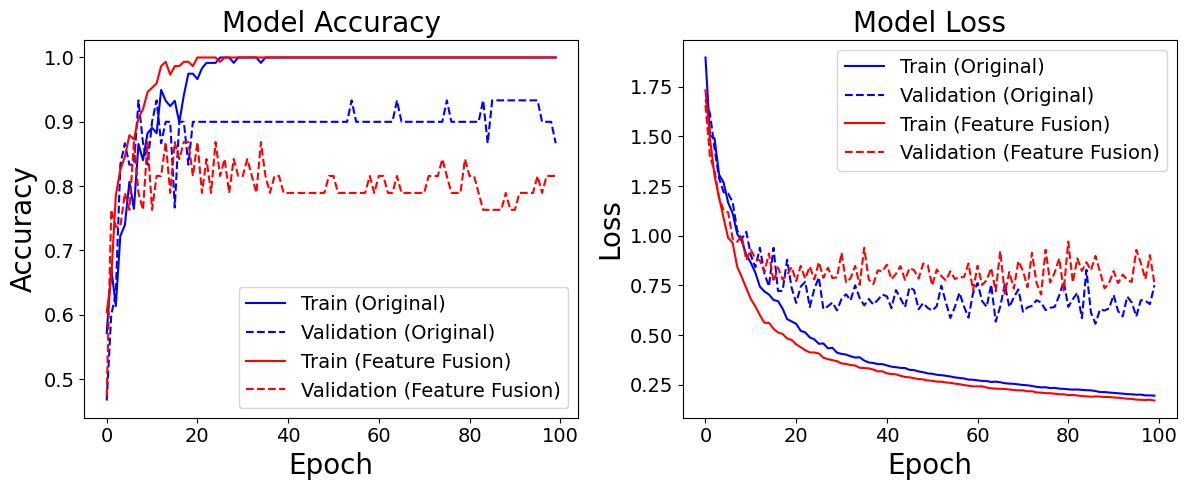

In [ ]:
# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_original.history['accuracy'], color='blue')
plt.plot(history_original.history['val_accuracy'], color='blue', linestyle='--')
plt.plot(history_feature_fusion.history['accuracy'], color='red')
plt.plot(history_feature_fusion.history['val_accuracy'], color='red', linestyle='--')
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(['Train (Original)', 'Validation (Original)', 'Train (Feature Fusion)', 'Validation (Feature Fusion)'], loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_original.history['loss'], color='blue')
plt.plot(history_original.history['val_loss'], color='blue', linestyle='--')
plt.plot(history_feature_fusion.history['loss'], color='red')
plt.plot(history_feature_fusion.history['val_loss'], color='red', linestyle='--')
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(['Train (Original)', 'Validation (Original)', 'Train (Feature Fusion)', 'Validation (Feature Fusion)'], loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

**Ensemble**

['DME' 'DR' 'DME' 'DME' 'DME' 'DME' 'DME' 'DME' 'DME' 'DME' 'DME' 'DME'
 'DME' 'DME' 'DME' 'DR' 'DME' 'DR' 'DME' 'DME' 'DME' 'DME' 'DME' 'DR'
 'DME' 'DR' 'DME' 'DR' 'DR' 'DR' 'DR' 'DR' 'DR' 'DR' 'DR' 'DR' 'DME' 'DR']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 722 (2.82 KB)

 Trainable params: 722 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 417ms/step - accuracy: 0.6818 - loss: 0.9154 - val_accuracy: 0.6333 - val_loss: 1.0447
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6518 - loss: 0.8489 - val_accuracy: 0.8333 - val_loss: 1.0632
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7221 - loss: 0.7896 - val_accuracy: 0.8333 - val_loss: 1.0931
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7490 - loss: 0.7047 - val_accuracy: 0.8333 - val_loss: 1.1153
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8513 - loss: 0.6524 - val_accuracy: 0.8333 - val_loss: 1.1420
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7125 - loss: 0.7000 - val_accuracy: 0.8333 - val_loss: 1.1638
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8491 - loss: 0.5952 - val_accuracy: 0.8333 - val_loss: 1.1877
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8709 - loss: 0.6087 - val_accuracy: 0.8

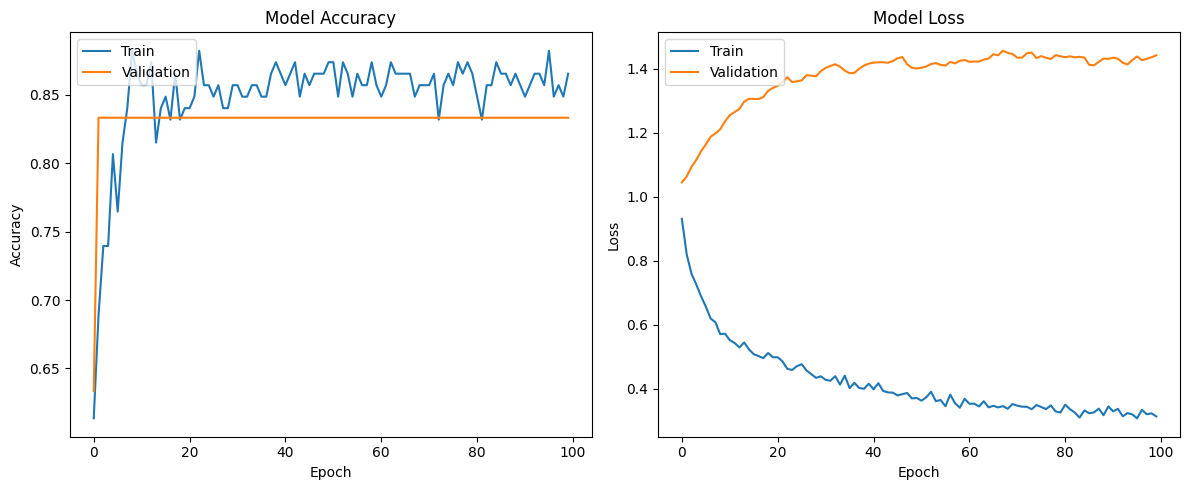

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step   
Accuracy: 0.8157894736842105
Precision: 0.8193745232646834
Recall: 0.8157894736842105
F1-Score: 0.8170058307912114
Average ROC AUC (OvR): 0.8095238095238095


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 12s/step - accuracy: 0.5167 - loss: 1.8260 - val_accuracy: 0.6579 - val_loss: 1.5908
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 318ms/step - accuracy: 0.6370 - loss: 1.6319 - val_accuracy: 0.6316 - val_loss: 1.5121
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 900ms/step - accuracy: 0.6279 - loss: 1.5457 - val_accuracy: 0.6579 - val_loss: 1.4956
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6555 - loss: 1.5201 - val_accuracy: 0.7105 - val_loss: 1.4031
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 976ms/step - accuracy: 0.6805 - loss: 1.4219 - val_accuracy: 0.6842 - val_loss: 1.3592
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 661ms/step - accuracy: 0.6204 - loss: 1.4166 - val_accuracy: 0.7105 - val_loss: 1.3169
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 552ms/step - accuracy: 0.6898 - loss: 1.3682 - val_accuracy: 0.6842 - val_loss: 1.2754
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 948ms/step - accuracy: 0.6791 - loss: 1.3648 - val_accuracy: 0.7368 - val_loss: 1.2470
Epoch 

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 96)        │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 110, 110, 192)       │         166,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 55, 55, 192)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 580800)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 384)                 │     223,027,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │             770 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,591,368 (2.49 GB)

 Trainable params: 223,197,122 (851.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 446,394,246 (1.66 GB)

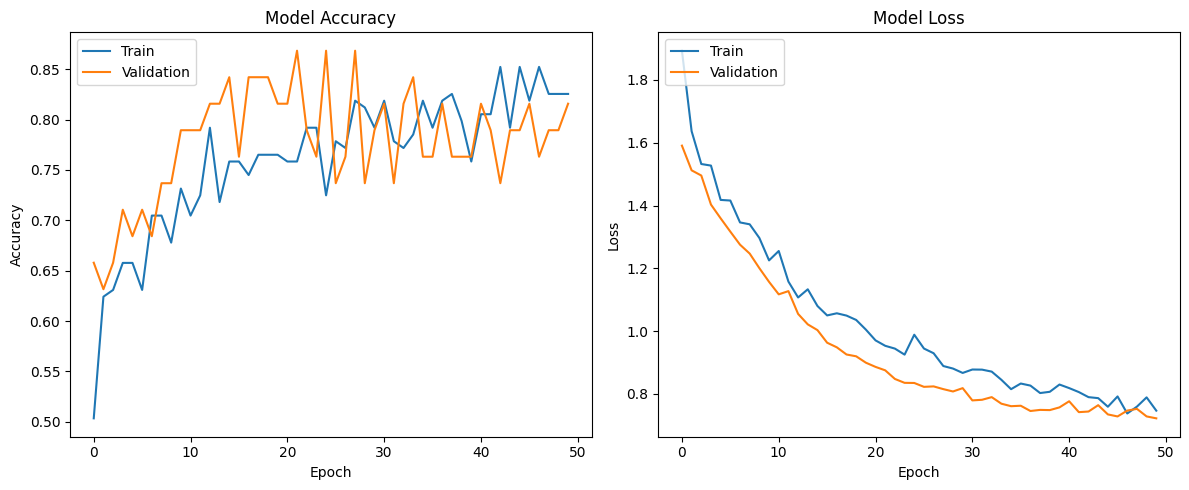

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step
Accuracy: 0.8157894736842105
Precision: 0.8193745232646834
Recall: 0.8157894736842105
F1-Score: 0.8170058307912114
Average ROC AUC (OvR): 0.8095238095238095
Accuracy: 0.8157894736842105
Precision: 0.8193745232646834
Recall: 0.8157894736842105
F1-Score: 0.8170058307912114
Average ROC AUC (OvR): 0.8095238095238095
SVM: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
NN: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
CNN: [0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1
 0]
Ensemble: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
Test: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
Ensemble Accuracy: 0.8157894736842105
Accuracy: 0.8157894736842105
Precision: 0.8193745232646834
Recall: 0.8157894736842105
F1-Score: 0.8170058307912114
Average ROC AUC (OvR): 0.8095238095238095


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, concatenate, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Extract binary Biomarkers
biomarkers = data.iloc[:, [2, 7, 11, 12]]

# Extract numerical Clinical Labels
clinical_labels = data.iloc[:, [18,19]]

# Extract Biomarkers and Clinical Labels
all_data = data.iloc[:, [2, 7, 11, 12] + [18, 19]]

# Extract data
X = biomarkers
x = StandardScaler().fit_transform(X)  # Scale data
x = pd.DataFrame(x, columns=X.columns) # Convert back to dataframe

y = data['Disease Label']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = to_categorical(y)

# Get the paths of successfully loaded images
loaded_image_paths = [path for path, img in zip(full_paths, images) if img is not None]

# Get the indices of absent images
absent_image_indices = [i for i, path in enumerate(full_paths) if path not in loaded_image_paths]

# Remove corresponding data from the original dataframes
x = x[~x.index.isin(absent_image_indices)]
data = data[~data.index.isin(absent_image_indices)]

eye_ids = data['Eye_ID']

# Create a GroupShuffleSplit instance
splitter = GroupShuffleSplit(test_size=0.2, random_state=42)

# Split data into training and testing sets
for train_indices, test_indices in splitter.split(x, groups=eye_ids):
    x_train = x.iloc[train_indices]
    x_test = x.iloc[test_indices]
    y_train = data.iloc[train_indices]['Disease Label']
    y_test = data.iloc[test_indices]['Disease Label']
    images_train = images[train_indices]
    images_test = images[test_indices]
    labels_train = labels[train_indices]
    labels_test = labels[test_indices]
    # y_train_1hot = y[train_indices]
    # y_test_1hot = y[test_indices]

#################### Support Vector Machine #################################

# Set up Support Vector model
# model = SVC(kernel='linear', probability = True)
# model = SVC(kernel='poly', degree=2)
model = SVC(kernel='rbf', gamma=1, C=1)
model.fit(x_train, y_train)

# Generate predicted disease labels
y_pred_SVM = model.predict(x_test)
print(y_pred_SVM)



################ Neural Network ################################

from keras.layers import Dense
from keras.models import Sequential

# Set up neural network
from keras.regularizers import l1, l2

num_inputs = x_train.shape[1]

model = Sequential()
model.add(Dense(32, input_shape = (num_inputs,), kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(16, activation = 'relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(2, activation = 'softmax'))

from keras.callbacks import EarlyStopping
early_stopping_monitor = EarlyStopping(patience=2)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics =['accuracy'])
print(model.summary())

# Encode labels for neural network
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_train = to_categorical(y_train)
y_test = label_encoder.fit_transform(y_test)
y_test = to_categorical(y_test)

# Train the model and capture the training history
history = model.fit(x_train, y_train, validation_split = 0.2, epochs = 100, batch_size = 8)#, callbacks=[early_stopping_monitor])

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

# Generate predicted disease labels
y_pred_NN = model.predict(x_test)
y_pred_NN = np.argmax(y_pred_NN, axis=1)
y_test = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_NN)
precision = precision_score(y_test, y_pred_NN, average='weighted')
recall = recall_score(y_test, y_pred_NN, average='weighted')
f1 = f1_score(y_test, y_pred_NN, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_NN, multi_class='ovr')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")



################### Convolutional Neural Network ######################

from tensorflow.keras.preprocessing.image import ImageDataGenerator

def add_noise(image):
    # Add noise
    noise = np.random.normal(loc=0.0, scale=0.05, size=image.shape)  # Adjust scale to change intensity
    noisy_image = image + noise
    # Clip the image to be within valid pixel range [0, 1]
    noisy_image = np.clip(noisy_image, 0., 1.)
    return noisy_image

# Augmentation function
train_datagen = ImageDataGenerator(
    rotation_range=10,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    zoom_range=0.5,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=add_noise
)

from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# # Split the data into training and testing sets
# images_train, images_test, labels_train, labels_test = train_test_split(
#     images, labels, test_size=0.2, random_state=42)

img_rows = images.shape[1]
img_cols = images.shape[2]
img_channels = images.shape[3]
num_classes = labels.shape[1]
num_filters = 96

# Build the model
model = Sequential()
model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
                 input_shape=(img_rows, img_cols, img_channels), padding = 'same',
                 dilation_rate = 2))#, kernel_regularizer=l1(0.01)))
model.add(MaxPool2D(2))
model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(MaxPool2D(2))
model.add(Flatten())
model.add(Dense(num_filters*4, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.00011114688286547925)))

# Compile the model
model.compile(optimizer=Adam(learning_rate=4.893049541904633e-05), loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model to the training data
history = model.fit(train_datagen.flow(images_train, labels_train, batch_size=50),
                    validation_data=(images_test, labels_test), validation_split=0.2, epochs=50)

# Evaluate the performance on the test data
evaluation_result = model.evaluate(images_test, labels_test)
print("Test Accuracy:", evaluation_result[1])

model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))


# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

# Predict labels and revert to one hot encoded
labels_pred = model.predict(images_test)
labels_pred = np.argmax(labels_pred, axis=1)
y_pred_CNN = labels_pred
# print(y_pred_CNN)
labels_test = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")


############## Combine Predictions ##########################

# Define weights for each model
weights = {
    'SVM': 0.3,
    'NN': 0.3,
    'CNN': 0.4,
}

# Ensure predictions are NumPy arrays
label_encoder = LabelEncoder()
y_pred_SVM = label_encoder.fit_transform(y_pred_SVM)
y_pred_SVM = np.array(y_pred_SVM)
y_pred_NN = np.array(y_pred_NN)
y_pred_CNN = np.array(y_pred_CNN)

accuracy = accuracy_score(y_test, y_pred_SVM)
precision = precision_score(y_test, y_pred_SVM, average='weighted')  # Adjust 'average' as needed
recall = recall_score(y_test, y_pred_SVM, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(y_test, y_pred_SVM, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(y_test, y_pred_SVM, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")

# Combine predictions using weighted averages
y_pred_ensemble = (
    weights['SVM'] * y_pred_SVM +
    weights['NN'] * y_pred_NN +
    weights['CNN'] * y_pred_CNN
)

# Get the final prediction by rounding to the nearest integer
y_pred_ensemble = np.round(y_pred_ensemble).astype(int)

print(f"SVM: {y_pred_SVM}")
print(f"NN: {y_pred_NN}")
print(f"CNN: {y_pred_CNN}")
print(f"Ensemble: {y_pred_ensemble}")
print(f"Test: {y_test}")

# Validate the combined predictions
accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"Ensemble Accuracy: {accuracy}")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_ensemble)
precision = precision_score(y_test, y_pred_ensemble, average='weighted')
recall = recall_score(y_test, y_pred_ensemble, average='weighted')
f1 = f1_score(y_test, y_pred_ensemble, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_ensemble, multi_class='ovr')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")



Vote based combination:

In [ ]:
from scipy.stats import mode

predictions = np.array([y_pred_SVM, y_pred_NN, y_pred_CNN])
# y_pred_ensemble_class = mode(predictions, axis=0).mode[0]
y_pred_ensemble_class = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)

print(y_pred_SVM)
print(y_pred_NN)
print(y_pred_CNN)
print(y_pred_ensemble_class)
print(y_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_ensemble_class)
precision = precision_score(y_test, y_pred_ensemble_class, average='weighted')
recall = recall_score(y_test, y_pred_ensemble_class, average='weighted')
f1 = f1_score(y_test, y_pred_ensemble_class, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_ensemble_class, multi_class='ovr')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
[0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1
 0]
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
Accuracy: 0.8157894736842105
Precision: 0.8193745232646834
Recall: 0.8157894736842105
F1-Score: 0.8170058307912114
Average ROC AUC (OvR): 0.8095238095238095


Optimised weighted average:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# # Define weights for each model
# weights = {
#     'SVM': 0.3,
#     'NN': 0.3,
#     'CNN': 0.4,
# }


def combine_predictions(weight_SVM, weight_NN, weight_CNN):

  # Combine predictions using weighted averages
  y_pred_ensemble = (
      weight_SVM * y_pred_SVM +
      weight_NN * y_pred_NN +
      weight_CNN * y_pred_CNN
  )

  # Get the final prediction by rounding to the nearest integer
  y_pred_ensemble = np.round(y_pred_ensemble).astype(int)
  return y_pred_ensemble

def caluculate_accuracy(y_pred_ensemble):
  accuracy = accuracy_score(y_test, y_pred_ensemble)
  return accuracy

accuracy = 0
optimised_weights = []

for weight_SVM in np.linspace(0,1,50):
  for weight_NN in np.linspace(0,1,50):
    for weight_CNN in np.linspace(0,1,50):

      y_pred_ensemble = combine_predictions(weight_SVM, weight_NN, weight_CNN)
      accuracy_new = caluculate_accuracy(y_pred_ensemble)

      if accuracy_new > accuracy:
        accuracy = accuracy_new
        optimised_weights = [weight_SVM, weight_NN, weight_CNN]


# Print the optimised weights
print("Optimized Weights:", optimised_weights)

# Use the optimised weights to make the final ensemble prediction
y_pred_ensemble = combine_predictions(optimised_weights[0], optimised_weights[1], optimised_weights[2])



print(f"SVM: {y_pred_SVM}")
print(f"NN: {y_pred_NN}")
print(f"CNN: {y_pred_CNN}")
print(f"Ensemble: {y_pred_ensemble}")
print(f"Test: {y_test}")

accuracy = accuracy_score(y_test, y_pred_ensemble)
precision = precision_score(y_test, y_pred_ensemble, average='weighted')  # Adjust 'average' as needed
recall = recall_score(y_test, y_pred_ensemble, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(y_test, y_pred_ensemble, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(y_test, y_pred_ensemble, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")

Optimized Weights: [0.0, 0.5102040816326531, 0.0]
SVM: [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 1]
NN: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0
 1]
CNN: [0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 0 1
 0]
Ensemble: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0
 1]
Test: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
Accuracy: 0.8157894736842105
Precision: 0.8139271255060729
Recall: 0.8157894736842105
F1-Score: 0.8142578668894458
Average ROC AUC (OvR): 0.7946428571428571


In [ ]:
print(labels_pred)
print(labels_test)
print(y_pred_CNN)
print(y_test)
1111111111111111

[1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0
 1]
[1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0
 1]
[1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0
 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]


1111111111111111